In [1]:
# CELL 1 - Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys; sys.path.append('../src')
from data_loader import load_data, get_missing_summary, check_duplicates, identify_column_types

In [2]:
# CELL 2 - Load data
df = load_data('../data/raw/Dataset for Data Analytics.xlsx')
df.head()

Shape: 1200 rows, 14 columns
OrderID                       str
Date               datetime64[us]
CustomerID                    str
Product                       str
Quantity                    int64
UnitPrice                 float64
ShippingAddress               str
PaymentMethod                 str
OrderStatus                   str
TrackingNumber                str
ItemsInCart                 int64
CouponCode                    str
ReferralSource                str
TotalPrice                float64
dtype: object


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [3]:
# CELL 3 - Shape & dtypes
print(df.shape)
df.info()

(1200, 14)
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(

In [4]:
# CELL 4 - Describe (numerical summary)
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [5]:
# CELL 5 - Missing values overview
missing_df = get_missing_summary(df)
missing_df

,missing_count,missing_pct
CouponCode,309,25.75
OrderID,0,0.00
CustomerID,0,0.00
Product,0,0.00
Quantity,0,0.00
Date,0,0.00
UnitPrice,0,0.00
ShippingAddress,0,0.00
OrderStatus,0,0.00
PaymentMethod,0,0.00


In [6]:
# CELL 6 - Duplicate check
dup_info = check_duplicates(df, subset_col='OrderID')
print(dup_info)

{'full_row_duplicates': np.int64(0), 'id_duplicates': np.int64(0)}


In [7]:
# CELL 7 - Column type identification
col_types = identify_column_types(df)
print(col_types)

{'numerical': ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice'], 'categorical': ['OrderID', 'CustomerID', 'Product', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'CouponCode', 'ReferralSource'], 'datetime': ['Date']}


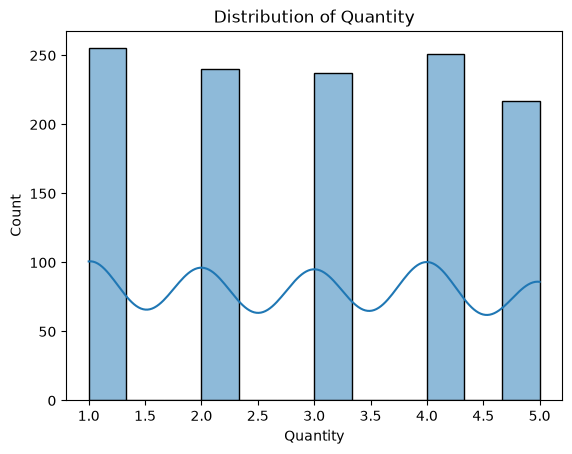

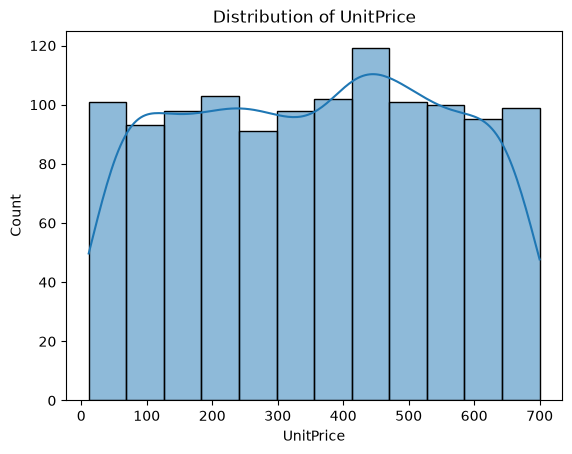

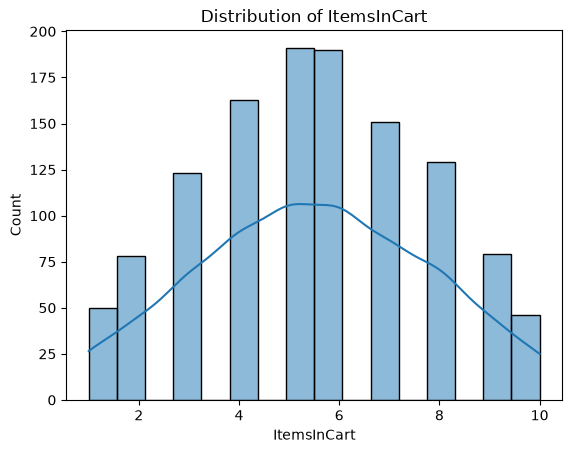

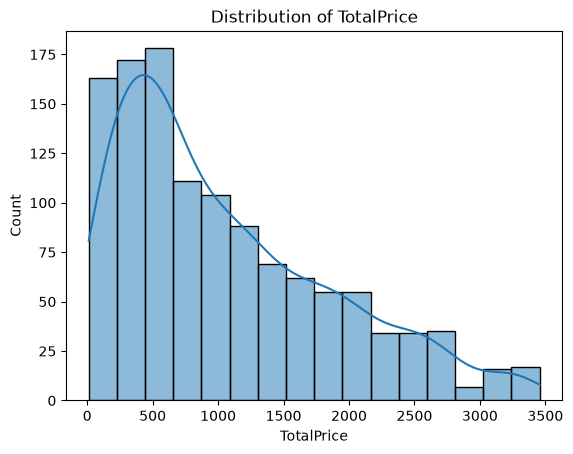

In [8]:
# CELL 8 - Numerical distributions (histograms)
numeric_cols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']
for col in numeric_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

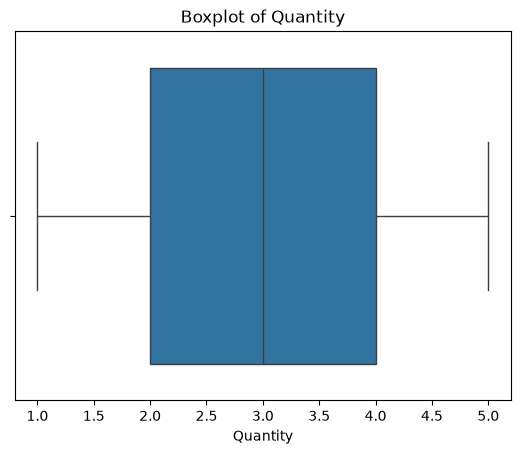

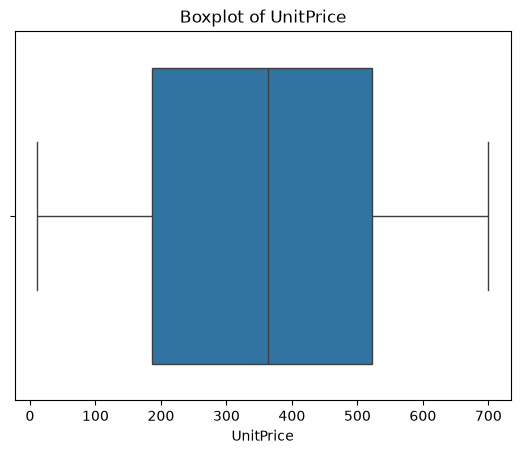

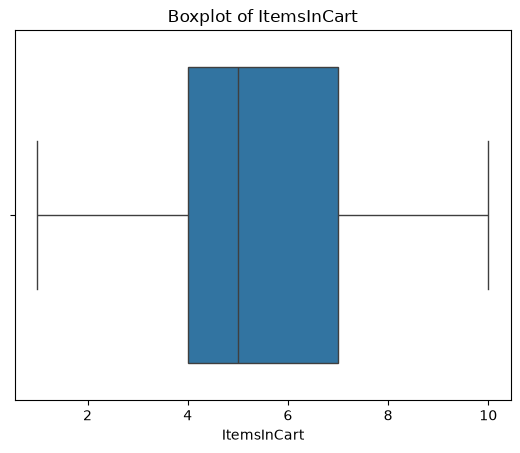

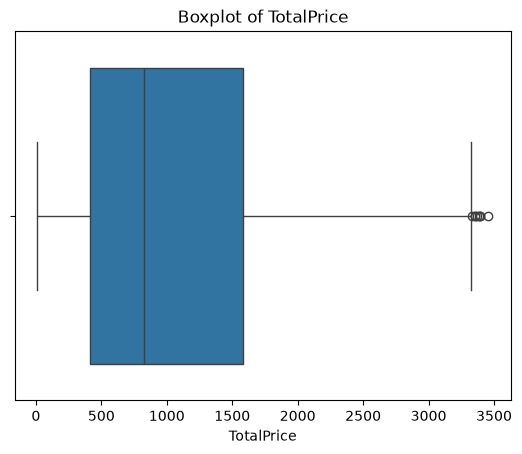

In [9]:
# CELL 9 - Boxplots (outlier hint)
for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

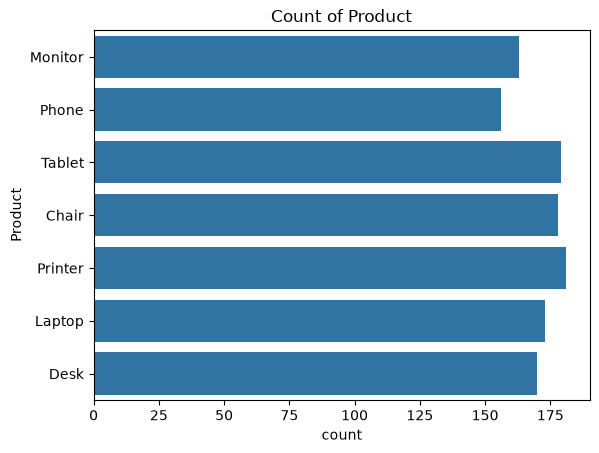

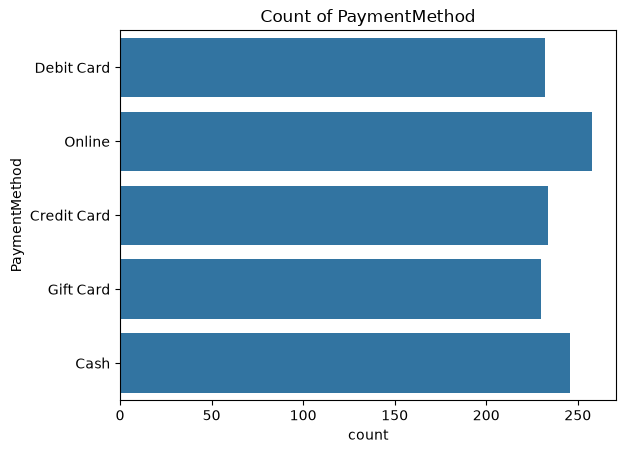

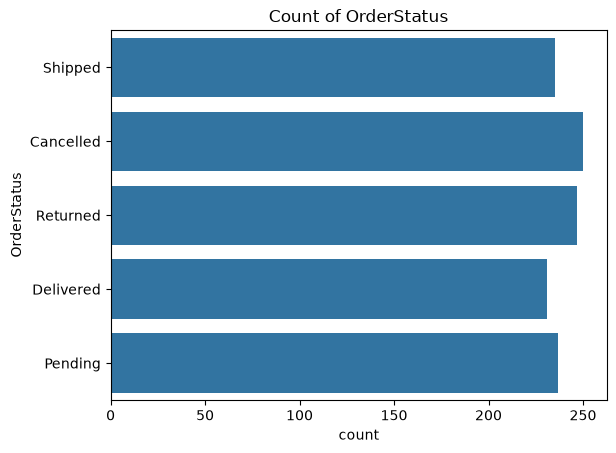

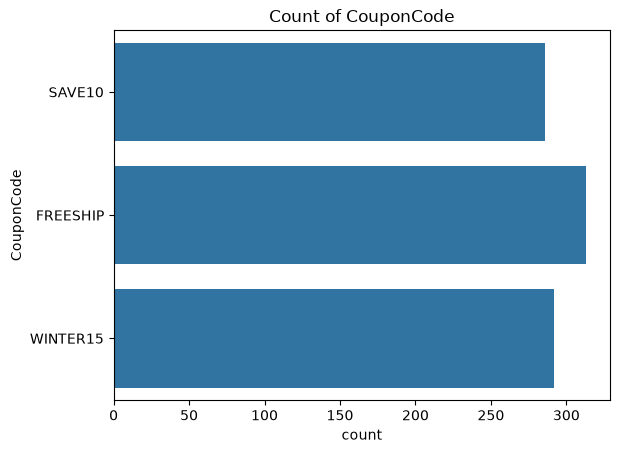

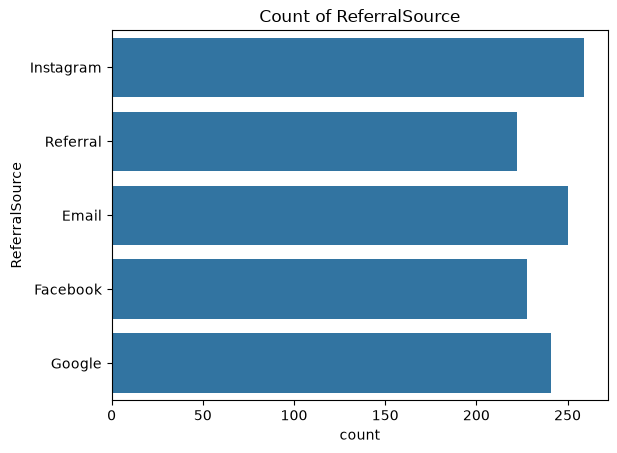

In [10]:
# CELL 10 - Categorical distributions (count plots)
cat_cols = ['Product', 'PaymentMethod', 'OrderStatus', 'CouponCode', 'ReferralSource']
for col in cat_cols:
    plt.figure()
    sns.countplot(y=df[col])
    plt.title(f'Count of {col}')
    plt.show()

## CELL 11 - Summary of Findings

- **Shape:** 1200 rows, 14 columns
- **Missing:** only `CouponCode` has missing values (~25.75%); all other columns have 0% missing
- **Duplicates:** none - 0 full-row duplicates and 0 duplicate `OrderID` values
- **Numerical ranges (from describe()):**
  - Quantity: 1 to 5 (mean ~2.95)
  - UnitPrice: 11.39 to 699.93 (mean ~356.41)
  - ItemsInCart: 1 to 10 (mean ~5.49)
  - TotalPrice: 11.39 to 3456.40 (mean ~1053.97)
  - Date range: 2023-01-01 to 2025-06-30
- **Categorical categories (from value_counts()):**
  - 9 distinct Products, multiple PaymentMethods / OrderStatuses / ReferralSources
  - CouponCode appears in ~74% of rows (NaN otherwise)